# CSC-321: Data Mining and Machine Learning
# Jordin Palmeri

## Assignment 8: Challenge Problem

### Part 1: Overview

I'm giving you the [Adult Working Wage](https://archive.ics.uci.edu/ml/datasets/adult) dataset. You can find out about it at the UCI ML Repository site.

This is the first time I'm giving you 'messy' data. That is, there is stuff missing, and formatting issues to deal with. I'm going to show you some steps you may need to perform on data like this.

Your job is simple, and NOT clearly defined. I want you to work with this data, and tell me a story. What can you find? What results do you get? What do they mean? What features are interesting. I'm NOT simply interested in you getting the max classification accuracy. I'm interested in what the features tell us about this data. So find ways to select, remove, or combine features, and use your machine learning skills to tell me about this data.

The only rule is that you must treat this as a **classification** task, and focus on classifying the **wage** feature.

If you're in any doubt, ask.

In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn import preprocessing

In [ ]:
labels = ['age','workclass','fnlwgt','education','education-num','marital-status','occupation','relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country','wage']
missing_values = ["?"]

train_url = "https://raw.githubusercontent.com/nixwebb/CSV_Data/master/Adult/adult.data"
test_url = "https://raw.githubusercontent.com/nixwebb/CSV_Data/master/Adult/adult.test"

adult_train = pd.read_csv(train_url,
                          names=labels,
                          na_values = missing_values,
                          skipinitialspace=True)
adult_test = pd.read_csv(test_url,names=labels,skiprows=1,na_values=missing_values,skipinitialspace=True)

pre_rows, pre_cols = adult_train.shape
pre_test_rows, pre_test_cols = adult_test.shape

print(f"Raw train shape: {pre_rows} rows, {pre_cols} columns")
print(f"Raw test shape: {pre_test_rows} rows, {pre_test_cols} columns")

adult_train.head()

Raw train shape: 32561 rows, 15 columns
Raw test shape: 16281 rows, 15 columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,wage
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
print("Train shape:", adult_train.shape)
print("Test shape:", adult_test.shape)

print("Unique wage values in train:", adult_train['wage'].unique())
print("Unique wage values in test:", adult_test['wage'].unique())

Train shape: (32561, 15)
Test shape: (16281, 15)
Unique wage values in train: ['<=50K' '>50K']
Unique wage values in test: ['<=50K.' '>50K.']


Here we explore the target variable 'wage'.
 - We notice that in the training data, wage values are `<=50K` and `>50K`.
 - In the test data, wage values are `<=50K.` and `>50K.`, which contain an extra period.

This inconsistency needs to be corrected to align the train and test sets.

Below, we remove the trailing period from the test data wage column.
After this step, the test set wage values match the training set: `<=50K` and `>50K`

In [ ]:
adult_test['wage'] = adult_test['wage'].str.replace(r'.', '')
print("Unique wage values in test after cleaning:", adult_test['wage'].unique())

Unique wage values in test after cleaning: ['<=50K' '>50K']


Missing values were represented by `"?"`, which are now `NaN`.
We’ll visualize them using the `missingno` library and count how many are missing.

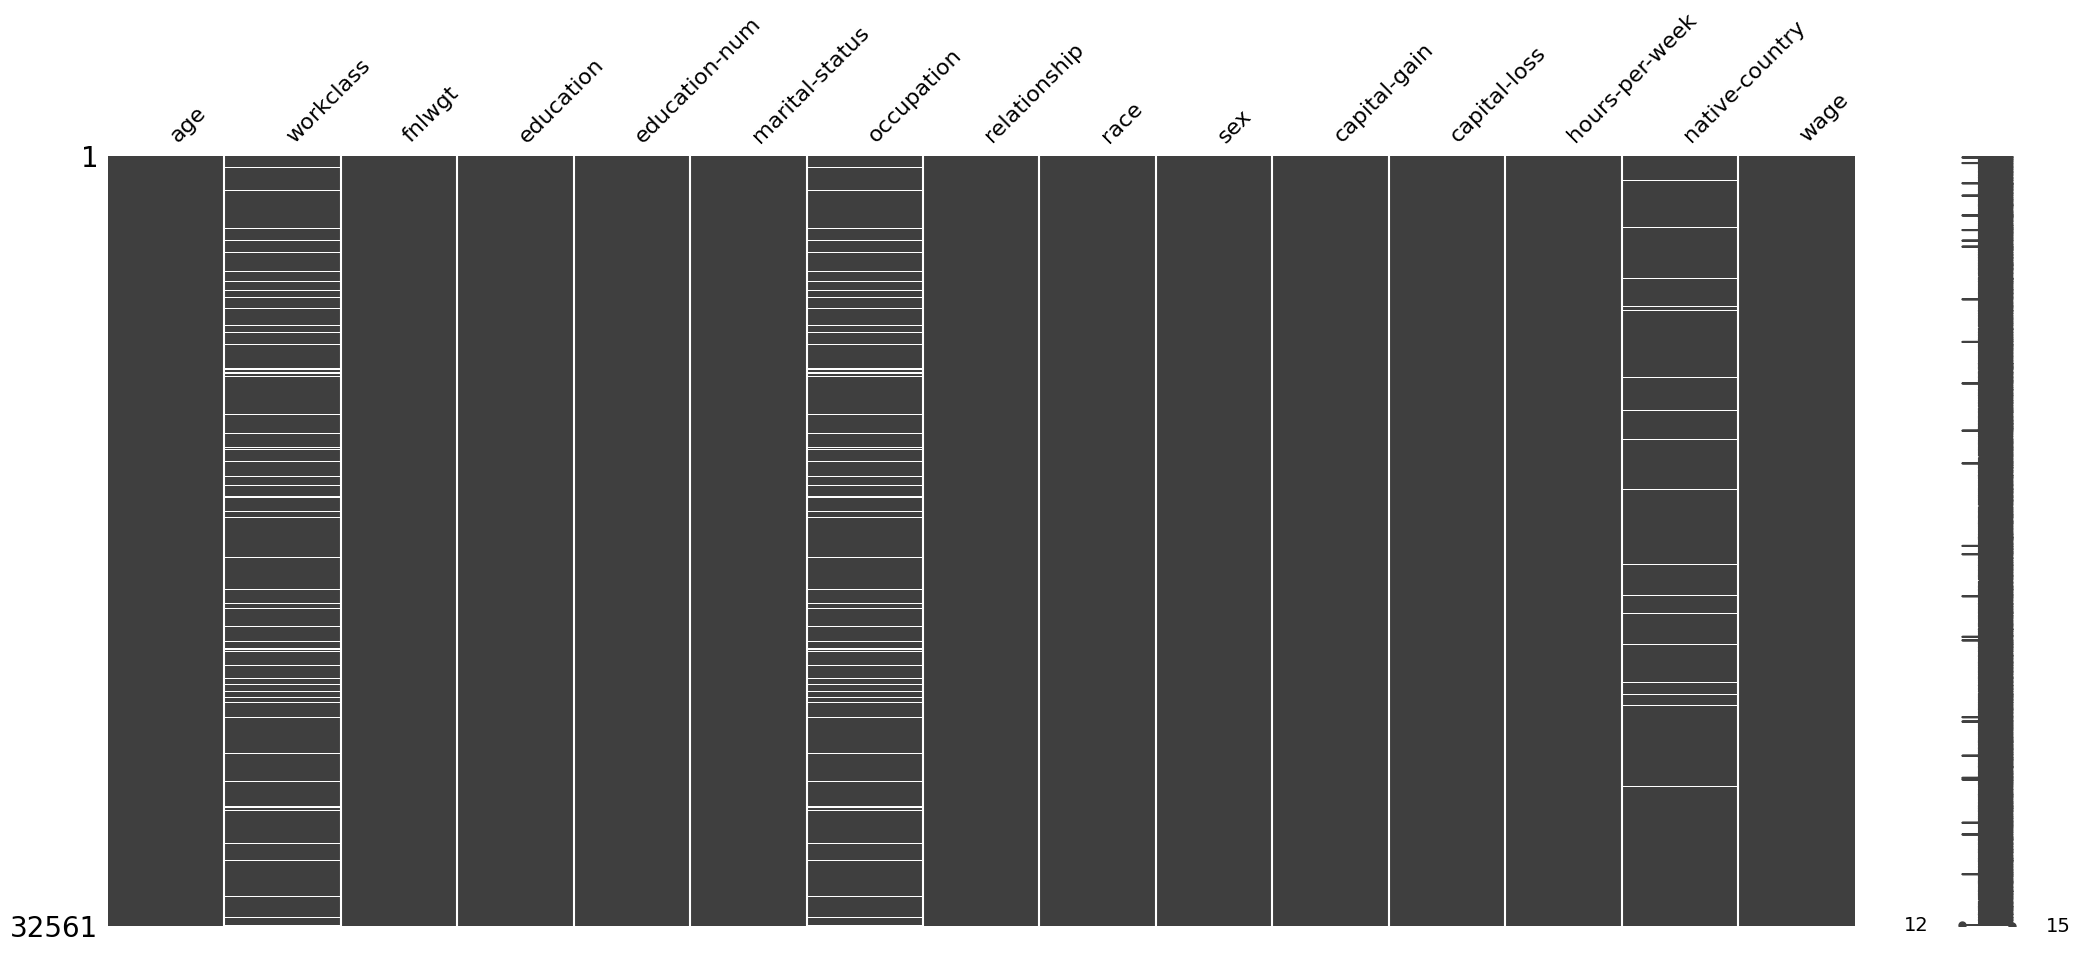

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
wage                 0
dtype: int64


In [ ]:
msno.matrix(adult_train)
plt.show()

print(adult_train.isna().sum())

We’ll drop rows with any missing values in both training and testing datasets.

In [ ]:
print("\nDropping all instances with NaN values\n")

adult_train = adult_train.dropna()
post_rows,post_cols = adult_train.shape
train_per = (pre_rows - post_rows) / pre_rows * 100

# I'm printing the total number of instances pre drop, post drop, and calculating the percentage dropped.

print("This is the reduced Adult wage TRAINING data set.\nIt has {} instances (down from {}), and it has {} features (-{:.2f}%)\n\n".format(post_rows,pre_rows,post_cols,train_per))

adult_test = adult_test.dropna()
post_test_rows,post_test_cols = adult_test.shape
test_per = (pre_test_rows - post_test_rows) / pre_test_rows * 100

print("This is the reduced Adult wage TEST data set.\nIt has {} instances (down from {}), and it has {} features (-{:.2f}%)\n\n".format(post_test_rows,pre_test_rows,post_test_cols,test_per))


Dropping all instances with NaN values

This is the reduced Adult wage TRAINING data set.
It has 30162 instances (down from 32561), and it has 15 features (-7.37%)


This is the reduced Adult wage TEST data set.
It has 15060 instances (down from 16281), and it has 15 features (-7.50%)




We’ll now use `LabelEncoder` for the `sex` and `wage` columns.

In [ ]:
le = preprocessing.LabelEncoder()
adult_train['sex'] = le.fit_transform(adult_train['sex'])
adult_test['sex'] = le.fit_transform(adult_test['sex'])
adult_train['wage'] = le.fit_transform(adult_train['wage'])
adult_test['wage'] = le.fit_transform(adult_test['wage'])

adult_train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,wage
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,1,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,1,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,1,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,1,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,0,40,Cuba,0


Above we convert categorical variables 'sex' and 'wage' into numeric values using `LabelEncoder`.
 - 'sex': Male=1, Female=0
 - 'wage': <=50K=0, >50K=1

In [ ]:
usa_train_data = adult_train[adult_train['native-country'] == 'United-States']

usa_rows,usa_cols = usa_train_data.shape
usa_per = (post_rows - usa_rows) / post_rows * 100

print("This is the USA Adult wage training data set.\nIt has {} instances (down from {}), and it has {} features (-{:.2f}%)\n\n".format(usa_rows,post_rows,usa_cols,usa_per))

# Repeat to test data

usa_test_data = adult_test[adult_test['native-country'] == 'United-States']


This is the USA Adult wage training data set.
It has 27504 instances (down from 30162), and it has 15 features (-8.81%)




We filter the dataset to include only instances where 'native-country' is 'United-States'.
 - This reduces the training data by approximately 8.8%.
 - This step simplifies encoding because 'native-country' has many unique values.

The filtered datasets are now ready for further preprocessing, like one-hot encoding.

In [ ]:
usa_train_data = pd.get_dummies(usa_train_data, columns=['workclass'], prefix_sep='_', drop_first=True)
usa_test_data = pd.get_dummies(usa_test_data, columns=['workclass'], prefix_sep='_', drop_first=True)

usa_train_data.head()

,age,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,wage,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,39,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,1,2174,0,40,United-States,0,False,False,False,False,True,False
1,50,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,1,0,0,13,United-States,0,False,False,False,True,False,False
2,38,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,1,0,0,40,United-States,0,False,True,False,False,False,False
3,53,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,1,0,0,40,United-States,0,False,True,False,False,False,False
5,37,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,0,0,0,40,United-States,0,False,True,False,False,False,False


Above we apply one-hot encoding to the 'workclass' feature.
 - Each unique category in 'workclass' becomes a separate binary column.
 - We drop the first column to avoid multicollinearity.

 Now let's repeat this for 'marital-status', 'relationship', and 'race'

In [ ]:
categorical_features = ['marital-status', 'relationship', 'race']

# Apply get_dummies to both train and test sets
usa_train_data = pd.get_dummies(usa_train_data, columns=categorical_features, prefix_sep='_', drop_first=True)
usa_test_data = pd.get_dummies(usa_test_data, columns=categorical_features, prefix_sep='_', drop_first=True)

# Check the first few rows to ensure it worked
usa_train_data.head()

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,77516,Bachelors,13,Adm-clerical,1,2174,0,40,United-States,...,False,True,False,False,False,False,False,False,False,True
1,50,83311,Bachelors,13,Exec-managerial,1,0,0,13,United-States,...,False,False,False,False,False,False,False,False,False,True
2,38,215646,HS-grad,9,Handlers-cleaners,1,0,0,40,United-States,...,False,True,False,False,False,False,False,False,False,True
3,53,234721,11th,7,Handlers-cleaners,1,0,0,40,United-States,...,False,False,False,False,False,False,False,True,False,False
5,37,284582,Masters,14,Exec-managerial,0,0,0,40,United-States,...,False,False,False,False,False,True,False,False,False,True


Now that I have all these features, I want to move 'wage' to be the last thing listed.

In [ ]:
# For train
cols_train = [col for col in usa_train_data.columns if col != 'wage'] + ['wage']
usa_train_data = usa_train_data[cols_train]

# For test
cols_test = [col for col in usa_test_data.columns if col != 'wage'] + ['wage']
usa_test_data = usa_test_data[cols_test]

# Verify
usa_train_data.head()

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,wage
0,39,77516,Bachelors,13,Adm-clerical,1,2174,0,40,United-States,...,True,False,False,False,False,False,False,False,True,0
1,50,83311,Bachelors,13,Exec-managerial,1,0,0,13,United-States,...,False,False,False,False,False,False,False,False,True,0
2,38,215646,HS-grad,9,Handlers-cleaners,1,0,0,40,United-States,...,True,False,False,False,False,False,False,False,True,0
3,53,234721,11th,7,Handlers-cleaners,1,0,0,40,United-States,...,False,False,False,False,False,False,True,False,False,0
5,37,284582,Masters,14,Exec-managerial,0,0,0,40,United-States,...,False,False,False,False,True,False,False,False,True,0


Now lets remove the `native-country` feature, since everyone we are looking at is in the United States.

In [ ]:
usa_train_data = usa_train_data.drop('native-country', axis=1)
usa_test_data = usa_test_data.drop('native-country', axis=1)

# Verify
usa_train_data.head()

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,wage
0,39,77516,Bachelors,13,Adm-clerical,1,2174,0,40,False,...,True,False,False,False,False,False,False,False,True,0
1,50,83311,Bachelors,13,Exec-managerial,1,0,0,13,False,...,False,False,False,False,False,False,False,False,True,0
2,38,215646,HS-grad,9,Handlers-cleaners,1,0,0,40,False,...,True,False,False,False,False,False,False,False,True,0
3,53,234721,11th,7,Handlers-cleaners,1,0,0,40,False,...,False,False,False,False,False,False,True,False,False,0
5,37,284582,Masters,14,Exec-managerial,0,0,0,40,False,...,False,False,False,False,True,False,False,False,True,0


Lets also drop `fnlwgt` from both the training and testing datasets because it doesn't represent a single person, so it wouldn't be good for accurate predictions.

In [ ]:
usa_train_data = usa_train_data.drop('fnlwgt', axis=1)
usa_test_data = usa_test_data.drop('fnlwgt', axis=1)

# Verify
usa_train_data.head()

,age,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,wage
0,39,Bachelors,13,Adm-clerical,1,2174,0,40,False,False,...,True,False,False,False,False,False,False,False,True,0
1,50,Bachelors,13,Exec-managerial,1,0,0,13,False,False,...,False,False,False,False,False,False,False,False,True,0
2,38,HS-grad,9,Handlers-cleaners,1,0,0,40,False,True,...,True,False,False,False,False,False,False,False,True,0
3,53,11th,7,Handlers-cleaners,1,0,0,40,False,True,...,False,False,False,False,False,False,True,False,False,0
5,37,Masters,14,Exec-managerial,0,0,0,40,False,True,...,False,False,False,False,True,False,False,False,True,0


Now lets create a heatmap to see how different feature correlate with eachother.

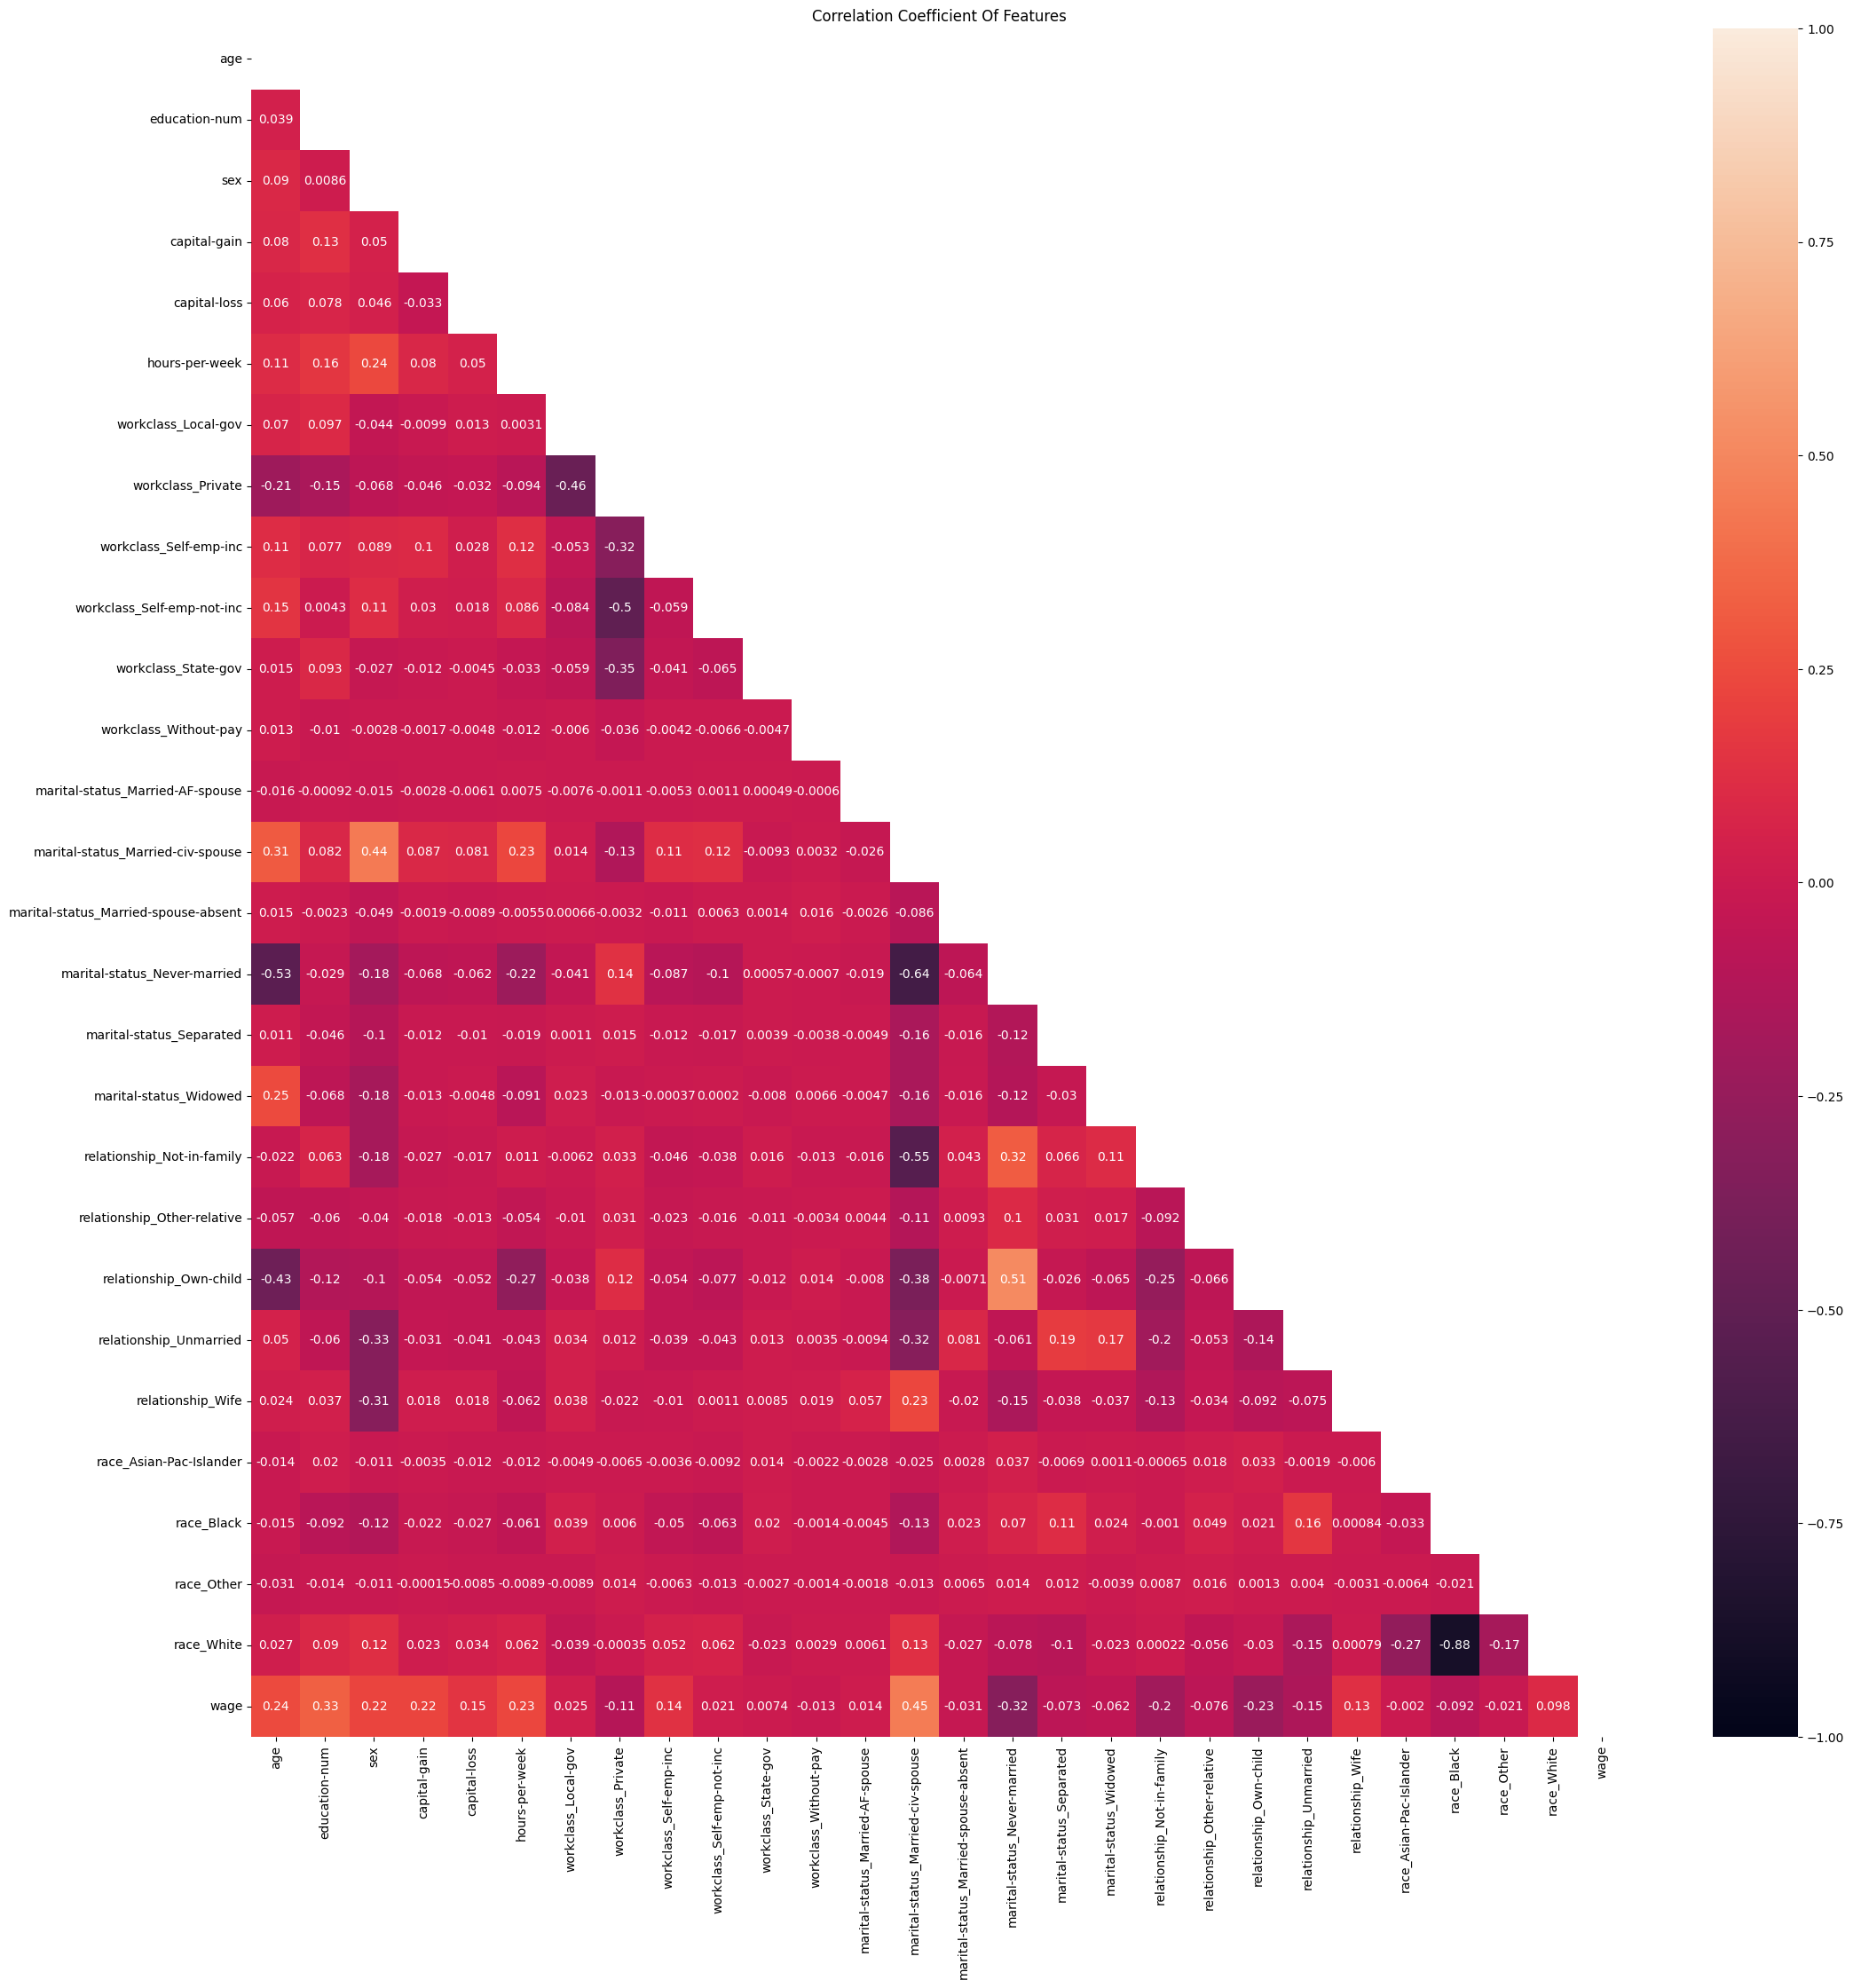

In [ ]:
tmp = usa_train_data.select_dtypes(include=['number','bool'])

# set figure size
plt.figure(figsize=(25,25))

# Generate a mask to onlyshow the bottom left triangle
mask = np.triu(np.ones_like(tmp.corr(), dtype=bool))

# generate heatmap
sns.heatmap(tmp.corr(), annot=True, mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Coefficient Of Features')
plt.show()

From the correlation heatmap, several key relationships are apparent:

 - Target correlations (wage):

    - The wage feature shows moderate positive correlation with education-num (0.33), marital-status_Married-civ-spouse (0.45), hours-per-week (0.23), age (0.24), and capital-gain (0.22). This suggests that higher education, being married, working longer hours, being older, and having capital gains are associated with earning more than $50K.

    - sex also has a positive correlation with wage (0.22), indicating some gender-related difference in wages.

 - Strong feature intercorrelations:

    - Among marital status dummies, marital-status_Never-married and marital-status_Married-civ-spouse are strongly negatively correlated (-0.64), which is expected due to their mutually exclusive nature.

 - Features with little impact on wage:

    - workclass dummies, capital-loss, and race dummies show very low correlations with wage, suggesting they may contribute little in a predictive model.

 - Implications for modeling:

    - For logistic regression, we can initially include all features.

    - For a reduced model, the most predictive features are likely: education-num, marital-status_Married-civ-spouse, hours-per-week, age, capital-gain, and sex.

    - Other features may be omitted for the simplified model without much loss in predictive power.

    - Finally, a zeroR baseline will provide a benchmark by predicting the most frequent wage class.


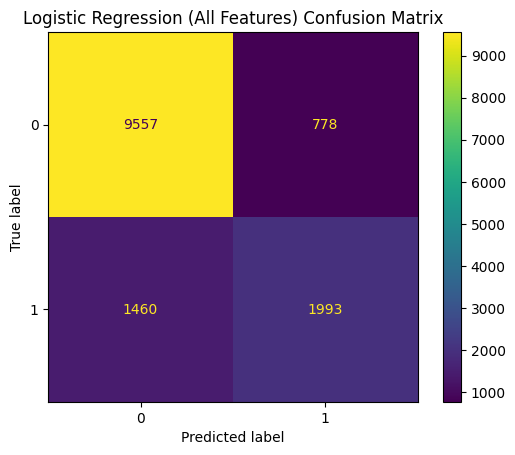

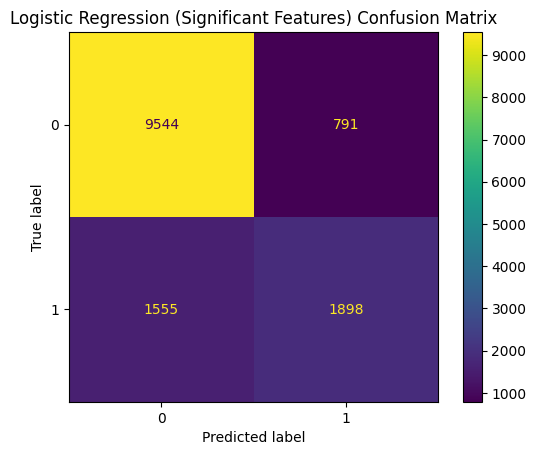

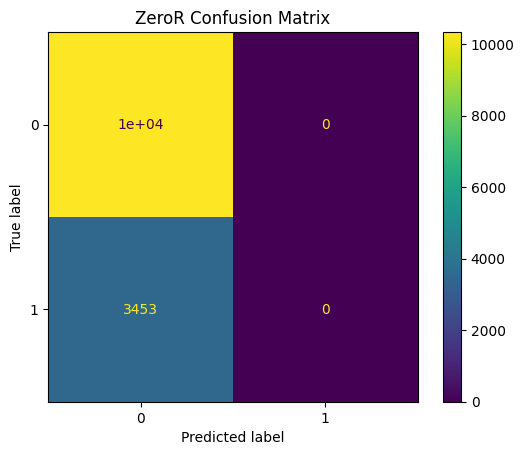

=== Results ===
Logistic Regression (All Features) Accuracy: 83.77%
Logistic Regression (Significant Features) Accuracy: 82.99%
ZeroR (Dummy Classifier) Accuracy: 74.96%


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# 1. Prepare Data
# -------------------------------
# Drop non-numeric and irrelevant columns
non_numeric_cols = ['education', 'occupation']
X_train_all = usa_train_data.drop(columns=non_numeric_cols + ['wage'])
X_test_all = usa_test_data.drop(columns=non_numeric_cols + ['wage'])
y_train = usa_train_data['wage']
y_test = usa_test_data['wage']

# Significant features (based on analysis)
sig_features = [
    'education-num',
    'hours-per-week',
    'capital-gain',
    'age',
    'sex',
    'marital-status_Married-civ-spouse'
]
X_train_sig = usa_train_data[sig_features]
X_test_sig = usa_test_data[sig_features]

# -------------------------------
# 2. Normalize Numeric Features using MinMaxScaler
# -------------------------------
scaler_all = MinMaxScaler()
scaler_all.fit(X_train_all)
X_train_all_scaled = scaler_all.transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)


scaler_sig = MinMaxScaler()
scaler_sig.fit(X_train_sig)
X_train_sig_scaled = scaler_sig.transform(X_train_sig)
X_test_sig_scaled = scaler_sig.transform(X_test_sig)


# -------------------------------
# 3. Logistic Regression - All Features
# -------------------------------
lr_all = LogisticRegression(max_iter=1000)
lr_all.fit(X_train_all_scaled, y_train)
lr_all_pred = lr_all.predict(X_test_all_scaled)
lr_all_acc = accuracy_score(y_test, lr_all_pred) * 100

cm_all = confusion_matrix(y_test, lr_all_pred)
ConfusionMatrixDisplay(cm_all, display_labels=lr_all.classes_).plot()
plt.title("Logistic Regression (All Features) Confusion Matrix")
plt.show()

# -------------------------------
# 4. Logistic Regression - Significant Features
# -------------------------------
lr_sig = LogisticRegression(max_iter=1000)
lr_sig.fit(X_train_sig_scaled, y_train)
lr_sig_pred = lr_sig.predict(X_test_sig_scaled)
lr_sig_acc = accuracy_score(y_test, lr_sig_pred) * 100

cm_sig = confusion_matrix(y_test, lr_sig_pred)
ConfusionMatrixDisplay(cm_sig, display_labels=lr_sig.classes_).plot()
plt.title("Logistic Regression (Significant Features) Confusion Matrix")
plt.show()

# -------------------------------
# 5. ZeroR (Most Frequent Class)
# -------------------------------
zr_clf = DummyClassifier(strategy="most_frequent")
zr_clf.fit(X_train_all_scaled, y_train)
zr_pred = zr_clf.predict(X_test_all_scaled)
zr_acc = accuracy_score(y_test, zr_pred) * 100

cm_zr = confusion_matrix(y_test, zr_pred)
ConfusionMatrixDisplay(cm_zr, display_labels=zr_clf.classes_).plot()
plt.title("ZeroR Confusion Matrix")
plt.show()

# -------------------------------
# 6. Print Summary of Results
# -------------------------------
print("=== Results ===")
print(f"Logistic Regression (All Features) Accuracy: {lr_all_acc:.2f}%")
print(f"Logistic Regression (Significant Features) Accuracy: {lr_sig_acc:.2f}%")
print(f"ZeroR (Dummy Classifier) Accuracy: {zr_acc:.2f}%")



Logistic Regression and ZeroR Results

 - Accuracy:

    - Logistic Regression (All Features): 83.77%

    - Logistic Regression (Significant Features): 82.99%

    - ZeroR (Most Frequent Class): 74.96%

 - Summary:

    - Both logistic regression models outperform ZeroR, showing they capture meaningful relationships in the data.

    - The model using all features performs slightly better than the one with only significant features. But its only slighly better meaning the the simpler model is probably the better one to use.

    - ZeroR predicts only the majority class (“≤50K”), resulting in lower accuracy.

 - Confusion Matrices (TN, FP, FN, TP):

    - All Features → 9557, 778, 1460, 1993

    - Significant Features → 9544, 791, 1555, 1898

    - ZeroR → 10000, 0, 3453, 0

 - Interpretation:

    - Logistic models correctly identify many high-income individuals (TP > 1800), while ZeroR fails to identify any.

    - False negatives remain notable, indicating the models still underpredict some high-income cases.